<a href="https://colab.research.google.com/github/asegura4488/EDCO_IntroCienciaDatos/blob/main/Semana5/EDA_Auto_MPG_Completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis exploratorio de datos (EDA) y selección de variables explicativas
## Caso aplicado: consumo de combustible de automóviles — Auto MPG

**Guía de clase con código completo y comentarios.** El objetivo es pasar de una tabla de datos a una selección **justificada** de variables para una regresión lineal.

**Pregunta de investigación:** ¿qué características de un automóvil permiten explicar su rendimiento de combustible, medido en millas por galón (`mpg`)?

**Aprenderemos a:**
1. Inspeccionar estructura, tipos, faltantes y registros repetidos.
2. Estudiar distribuciones con histogramas, diagramas de caja y valores atípicos.
3. Resumir grupos con `groupby`, `agg`, `cut`/`qcut` y tablas dinámicas.
4. Investigar asociaciones con diagramas de dispersión y correlaciones.
5. Identificar variables explicativas candidatas **sin confundir correlación con causalidad**.
6. Comparar modelos de regresión con validación cruzada y evaluar el elegido con datos no vistos.

> **Conexión con tu notebook anterior:** allí ajustabas un plano a variables `X0`, `X1` e `Y` provenientes de otro archivo. Aquí cambiamos a datos reales: `Y = mpg`, y buscamos qué columnas pueden formar `X` antes de ajustar un modelo. La idea matemática de mínimos cuadrados sigue siendo la misma.

**Duración sugerida:** 1 o 2 sesiones, según cuánto se discutan las gráficas. Todas las celdas se pueden ejecutar en orden. No necesita montar Google Drive.

## 0. Conceptos: variable objetivo y explicativas

- **Variable dependiente (`y`)**: `mpg`, millas recorridas por galón de combustible. Un valor mayor significa mejor rendimiento.
- **Variables cuantitativas**: `weight` (peso), `horsepower` (potencia), `displacement` (cilindrada), `acceleration` (tiempo de aceleración), `model_year` (año del modelo codificado del 70 al 82).
- **Variables discretas**: `cylinders` (número de cilindros). Puede estudiarse numéricamente, pero para comparar grupos resulta natural tratarla como categoría.
- **Variable categórica nominal**: `origin`, codificada como 1 = EE. UU., 2 = Europa, 3 = Japón. **No tiene sentido** suponer que la distancia entre 1 y 2 represente un efecto físico comparable al de 2 y 3.
- **Texto / identificador descriptivo**: `car_name`. No lo usaremos directamente como predictor numérico.

**Advertencia metodológica:** una correlación fuerte no prueba causalidad ni garantiza que una variable aporte información *adicional* frente a las demás. Por ejemplo, peso, cilindrada y potencia pueden describir en parte el mismo fenómeno.

In [1]:
# Si te falta algún paquete en Colab, descomenta esta línea:
# %pip install numpy pandas matplotlib seaborn scikit-learn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
SEMILLA = 42
print("Entorno preparado. Version de pandas:", pd.__version__)

Entorno preparado. Version de pandas: 2.2.3


In [24]:
# Necesitamos explorar la estructura de directorios
import os
from google.colab import drive
from google.colab import files
drive.mount('/content/drive', force_remount=True)
# Necesito ir a la carpeta del curso
os.chdir('/content/drive/MyDrive/EDCO_IntroCienciaDatos/Semana5/Datos')

Mounted at /content/drive


## 1. Carga y primera inspección

Coloca `Auto_MPG_UCI(2).csv` en la **misma carpeta que este notebook** (incluido el archivo en el ZIP de entrega). En Google Colab, si no está disponible, aparecerá un selector para subirlo.

**Preguntas para el grupo:** ¿cuántas observaciones hay?, ¿cuáles son las columnas?, ¿qué tipo de información almacena cada una?

In [25]:
candidatos = [Path("Auto_MPG_UCI(2).csv"), Path("Auto_MPG_UCI.csv")]
ruta_csv = next((p for p in candidatos if p.is_file()), None)

if ruta_csv is None:
    try:
        from google.colab import files
        print("Selecciona el archivo CSV de Auto MPG desde tu equipo:")
        archivos_subidos = files.upload()
        csv_subidos = [Path(nombre) for nombre in archivos_subidos if nombre.lower().endswith(".csv")]
        if not csv_subidos:
            raise FileNotFoundError("No se selecciono un archivo CSV.")
        ruta_csv = csv_subidos[0]
    except ImportError as exc:
        raise FileNotFoundError(
            "Coloca Auto_MPG_UCI(2).csv en la misma carpeta que el notebook y ejecuta de nuevo."
        ) from exc

datos = pd.read_csv(ruta_csv)
# Convertir columnas esperadas a numeros: robusto ante '?' en otras versiones del dataset.
for columna in ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin"]:
    datos[columna] = pd.to_numeric(datos[columna], errors="coerce")

datos["origen_nombre"] = datos["origin"].map({1: "EE. UU.", 2: "Europa", 3: "Japon"})

print("Archivo cargado:", ruta_csv)
print(f"Observaciones: {datos.shape[0]} | Columnas: {datos.shape[1]}")
display(datos.head(8))
print("Tipos de datos:")
display(datos.dtypes.to_frame("tipo"))

Archivo cargado: Auto_MPG_UCI.csv
Observaciones: 398 | Columnas: 10


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,origen_nombre
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,EE. UU.
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,EE. UU.
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,EE. UU.
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,EE. UU.
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino,EE. UU.
5,15.0,8,429.0,198.0,4341.0,10.0,70,1,ford galaxie 500,EE. UU.
6,14.0,8,454.0,220.0,4354.0,9.0,70,1,chevrolet impala,EE. UU.
7,14.0,8,440.0,215.0,4312.0,8.5,70,1,plymouth fury iii,EE. UU.


Tipos de datos:


,tipo
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,float64
acceleration,float64
model_year,int64
origin,int64
car_name,object
origen_nombre,object


### 1.1 Calidad de datos: faltantes y duplicados

Los **valores faltantes** pueden provocar errores o sesgar un análisis. Los **duplicados exactos** podrían representar una carga repetida, aunque a veces dos observaciones legítimas tienen datos idénticos. Antes de borrar algo, hay que investigar.

En este CSV hay **398 automóviles** y **6 valores ausentes de `horsepower`**. No es necesario eliminar esos automóviles: para modelar podemos reemplazar la potencia faltante por la **mediana de los datos de entrenamiento**.

,tipo,faltantes,% faltante,distintos
horsepower,float64,6,1.51,93
mpg,float64,0,0.00,129
cylinders,int64,0,0.00,5
displacement,float64,0,0.00,82
weight,float64,0,0.00,351
acceleration,float64,0,0.00,95
model_year,int64,0,0.00,13
origin,int64,0,0.00,3
car_name,object,0,0.00,305
origen_nombre,object,0,0.00,3


Filas duplicadas exactamente: 0


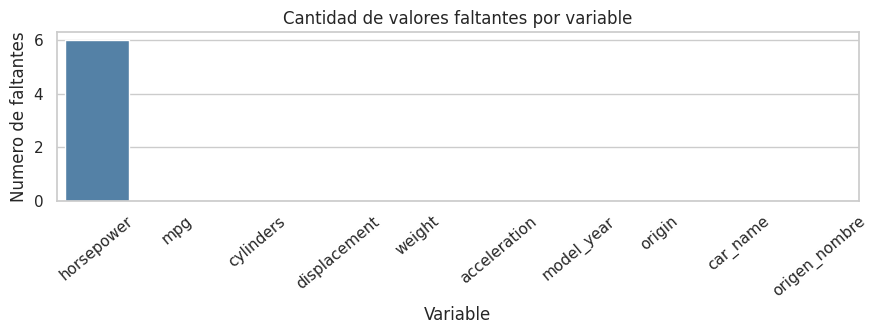

In [4]:
resumen_calidad = pd.DataFrame({
    "tipo": datos.dtypes.astype(str),
    "faltantes": datos.isna().sum(),
    "% faltante": (100 * datos.isna().mean()).round(2),
    "distintos": datos.nunique(dropna=True)
}).sort_values("faltantes", ascending=False)

display(resumen_calidad)
print("Filas duplicadas exactamente:", datos.duplicated().sum())

fig, ax = plt.subplots(figsize=(9, 3.5))
faltantes = datos.isna().sum().sort_values(ascending=False)
sns.barplot(x=faltantes.index, y=faltantes.values, ax=ax, color="steelblue")
ax.set(title="Cantidad de valores faltantes por variable", xlabel="Variable", ylabel="Numero de faltantes")
ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

### 1.2 Separación entrenamiento / prueba ANTES de seleccionar predictores

Para una clase de EDA es tentador usar todas las filas para decidir qué variables son importantes. **Sin embargo, si después evaluamos un modelo en una muestra de prueba, esta muestra debe permanecer reservada**; de lo contrario, las decisiones ya estuvieron influenciadas por los datos de prueba.

Por eso usamos primero `train_test_split` y realizamos el análisis exploratorio **para seleccionar variables** sobre el conjunto de **entrenamiento** (`eda`). Podemos reportar estadísticas descriptivas del total, pero **no elegiremos predictores mirando el conjunto de prueba**.

In [5]:
entrenamiento, prueba = train_test_split(datos, test_size=0.20, random_state=SEMILLA)
eda = entrenamiento.copy()

print("Entrenamiento (para EDA y seleccion de modelo):", len(entrenamiento))
print("Prueba (reservado hasta el final):", len(prueba))
print("Porcentaje reservado para prueba:", round(100 * len(prueba) / len(datos), 1), "%")

Entrenamiento (para EDA y seleccion de modelo): 318
Prueba (reservado hasta el final): 80
Porcentaje reservado para prueba: 20.1 %


## 2. Estadística descriptiva: ¿cómo se distribuyen las variables?

`describe()` resume conteo, media, desviación estándar, mínimos, máximos y cuantiles. Para observar una **distribución completa** necesitamos gráficos. **Media** y **mediana** pueden diferir cuando hay asimetrías o valores extremos.

,count,mean,std,min,25%,50%,75%,max
mpg,318.0,23.61,7.93,9.0,17.5,22.45,29.72,46.6
cylinders,318.0,5.43,1.68,3.0,4.0,4.00,6.00,8.0
displacement,318.0,191.90,102.98,68.0,98.5,148.50,259.50,455.0
horsepower,313.0,103.28,37.36,46.0,75.0,92.00,122.00,225.0
weight,318.0,2969.02,840.62,1613.0,2220.0,2822.50,3597.25,5140.0
acceleration,318.0,15.64,2.76,8.0,13.9,15.50,17.30,24.8
model_year,318.0,76.10,3.60,70.0,73.0,76.00,79.00,82.0


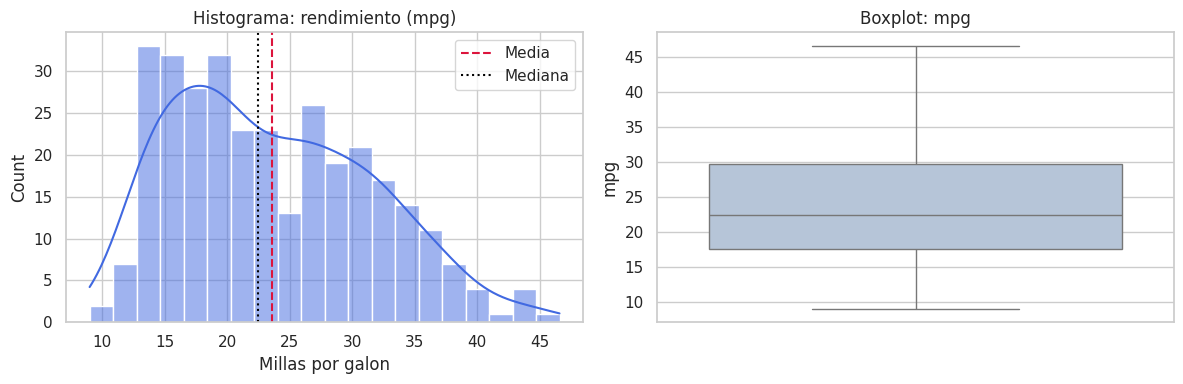

In [6]:
variables_numericas = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
display(eda[variables_numericas].describe().T.round(2))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=eda, x="mpg", bins=20, kde=True, ax=axs[0], color="royalblue")
axs[0].axvline(eda["mpg"].mean(), ls="--", c="crimson", label="Media")
axs[0].axvline(eda["mpg"].median(), ls=":", c="black", label="Mediana")
axs[0].set(title="Histograma: rendimiento (mpg)", xlabel="Millas por galon")
axs[0].legend()
sns.boxplot(y=eda["mpg"], ax=axs[1], color="lightsteelblue")
axs[1].set(title="Boxplot: mpg", ylabel="mpg")
plt.tight_layout()
plt.show()

### ¿Cómo se lee un histograma y un boxplot?

- **Histograma:** cada barra cuenta cuántos autos caen en un intervalo; informa concentración, dispersión, asimetría y posibles subgrupos. La curva KDE es una versión suavizada, no un ajuste predictivo.
- **Boxplot:** la caja va del primer al tercer cuartil (`Q1`–`Q3`), la línea central es la mediana, y los bigotes se extienden hasta las observaciones dentro de `1.5 × IQR`. Los puntos más allá son **posibles valores atípicos**, no necesariamente errores.

**Actividad oral:** localiza un valor de `mpg` alto. ¿Es razonable eliminarlo solo por estar fuera de un bigote?

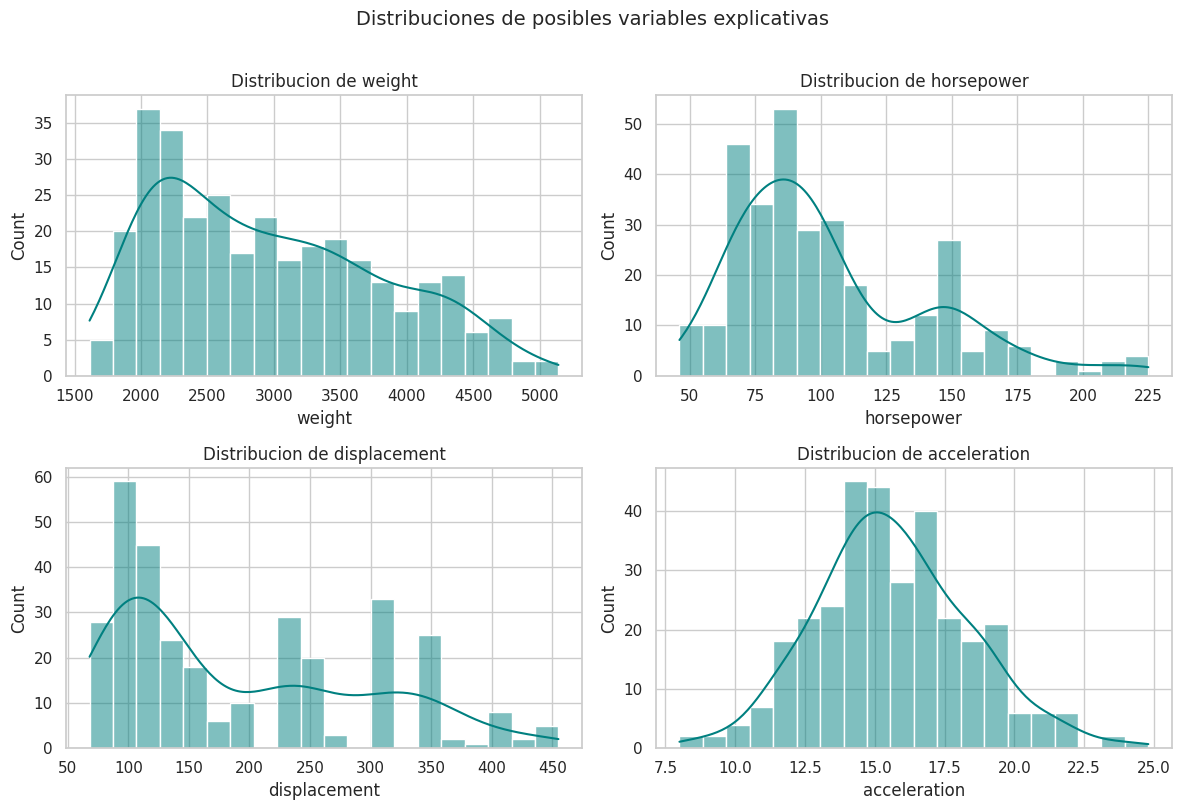

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for ax, variable in zip(axs.ravel(), ["weight", "horsepower", "displacement", "acceleration"]):
    sns.histplot(data=eda, x=variable, bins=20, kde=True, ax=ax, color="teal")
    ax.set_title(f"Distribucion de {variable}")
plt.suptitle("Distribuciones de posibles variables explicativas", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 2.1 Valores extremos con la regla del rango intercuartílico

Se define `IQR = Q3 − Q1`. Consideramos candidatos a atípicos los valores menores que `Q1 − 1.5 IQR` o mayores que `Q3 + 1.5 IQR`.

**No borraremos filas automáticamente.** En este conjunto un automóvil muy pesado o de muy alto rendimiento puede ser una observación válida y relevante para el modelo.

,variable,limite_inferior,limite_superior,n_candidatos
0,mpg,-0.84,48.06,0
1,weight,154.12,5663.12,0
2,horsepower,4.50,192.50,10
3,displacement,-143.00,501.00,0
4,acceleration,8.80,22.40,5


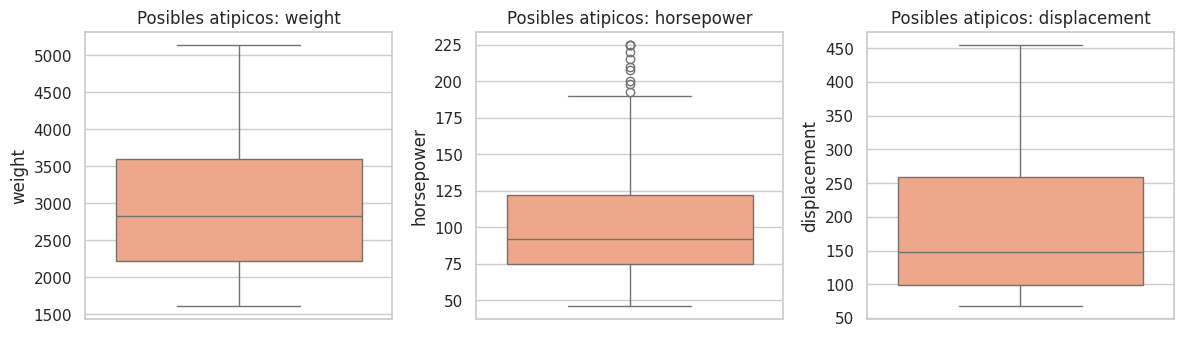

In [8]:
registro_atipicos = []
for v in ["mpg", "weight", "horsepower", "displacement", "acceleration"]:
    q1, q3 = eda[v].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((eda[v] < lim_inf) | (eda[v] > lim_sup)).sum())
    registro_atipicos.append({"variable": v, "limite_inferior": lim_inf,
                               "limite_superior": lim_sup, "n_candidatos": n})
display(pd.DataFrame(registro_atipicos).round(2))

fig, axs = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, v in zip(axs, ["weight", "horsepower", "displacement"]):
    sns.boxplot(y=eda[v], ax=ax, color="lightsalmon")
    ax.set_title(f"Posibles atipicos: {v}")
plt.tight_layout()
plt.show()

## 3. Agrupaciones con `groupby`: comparar subpoblaciones

`groupby` **divide** el DataFrame en grupos definidos por una o más columnas; `agg` aplica estadísticas y después reúne los resultados. Es una de las operaciones más útiles para transformar datos en evidencia.

Por ejemplo:

```python
eda.groupby("cylinders")["mpg"].mean()
```

responde: *¿cuál es el rendimiento promedio de los autos con 4, 6 u 8 cilindros?* Conviene acompañar el promedio con el **tamaño de cada grupo**, mediana y desviación estándar.

,cylinders,n_autos,mpg_promedio,mpg_mediana,mpg_desviacion,peso_promedio
0,3,4,20.55,20.25,2.56,2398.50
1,4,162,29.51,29.00,5.77,2304.94
2,5,3,27.37,25.40,8.23,3103.33
3,6,70,19.80,19.00,3.94,3249.03
4,8,79,14.89,14.00,2.78,4106.46


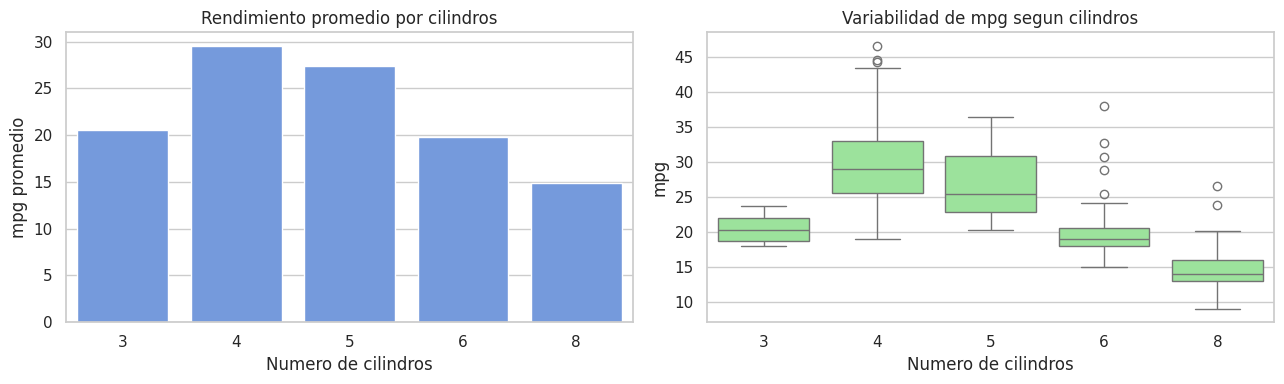

In [9]:
por_cilindros = (eda.groupby("cylinders", as_index=False)
                  .agg(n_autos=("mpg", "size"),
                       mpg_promedio=("mpg", "mean"),
                       mpg_mediana=("mpg", "median"),
                       mpg_desviacion=("mpg", "std"),
                       peso_promedio=("weight", "mean"))
                  .sort_values("cylinders"))
display(por_cilindros.round(2))

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=por_cilindros, x="cylinders", y="mpg_promedio", ax=axs[0], color="cornflowerblue")
axs[0].set(title="Rendimiento promedio por cilindros", xlabel="Numero de cilindros", ylabel="mpg promedio")
sns.boxplot(data=eda, x="cylinders", y="mpg", ax=axs[1], color="lightgreen")
axs[1].set(title="Variabilidad de mpg segun cilindros", xlabel="Numero de cilindros", ylabel="mpg")
plt.tight_layout()
plt.show()

**Interpretación para discutir:** en este archivo, los grupos de 4 cilindros suelen tener mayor `mpg` que los de 8 cilindros. También se observa que los de 8 cilindros tienden a pesar más. Esto sugiere una pregunta: **¿los cilindros aportan información distinta del peso, o ambas variables capturan parcialmente el mismo fenómeno?**

**Precaución:** los grupos de 3 y 5 cilindros tienen muy pocas observaciones; sus medias son poco estables.

,origen_nombre,n_autos,mpg_promedio,mpg_mediana,peso_promedio
0,EE. UU.,196,20.01,18.15,3368.74
1,Europa,56,28.26,27.60,2431.93
2,Japon,66,30.33,31.55,2237.65


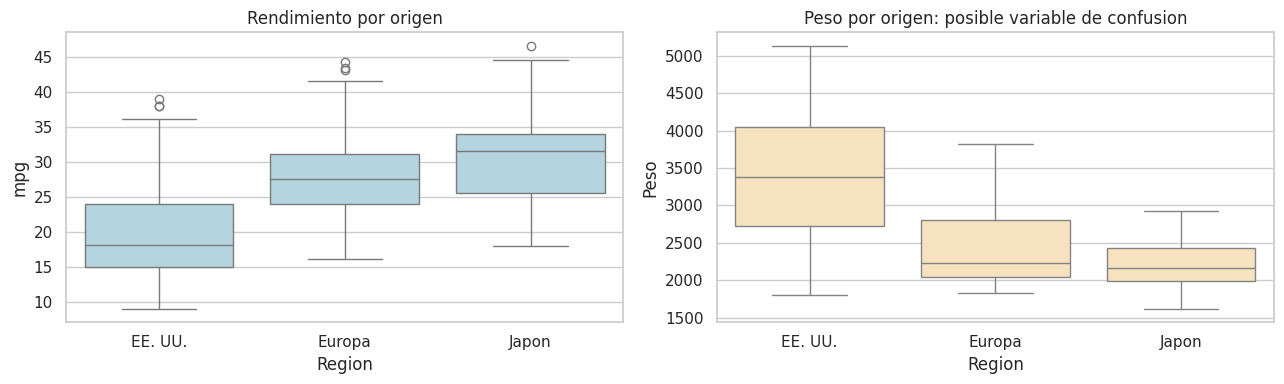

In [10]:
por_origen = (eda.groupby("origen_nombre", as_index=False)
              .agg(n_autos=("mpg", "size"),
                   mpg_promedio=("mpg", "mean"),
                   mpg_mediana=("mpg", "median"),
                   peso_promedio=("weight", "mean"))
              .sort_values("mpg_promedio"))
display(por_origen.round(2))

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=eda, x="origen_nombre", y="mpg", order=["EE. UU.", "Europa", "Japon"], ax=axs[0], color="lightblue")
axs[0].set(title="Rendimiento por origen", xlabel="Region", ylabel="mpg")
sns.boxplot(data=eda, x="origen_nombre", y="weight", order=["EE. UU.", "Europa", "Japon"], ax=axs[1], color="moccasin")
axs[1].set(title="Peso por origen: posible variable de confusion", xlabel="Region", ylabel="Peso")
plt.tight_layout()
plt.show()

### 3.1 Agrupar por dos variables a la vez

Ahora controlamos parcialmente la comparación: en lugar de comparar regiones globalmente, mostramos los `mpg` **para cada combinación de región y cilindros**.

```python
eda.groupby(["origen_nombre", "cylinders"])["mpg"].agg(["count", "mean"])
```

La tabla pivote reorganiza los mismos resultados para leerlos como una matriz; una celda vacía indica que **no hay observaciones** de esa combinación en entrenamiento.

n_autos  promedio  mediana
origen_nombre cylinders                            
EE. UU.       4               56     27.98    27.10
              6               61     19.33    19.00
              8               79     14.89    14.00
Europa        4               50     28.74    28.00
              5                3     27.37    25.40
              6                3     21.13    16.50
Japon         3                4     20.55    20.25
              4               56     31.72    32.00
              6                6     23.88    23.10

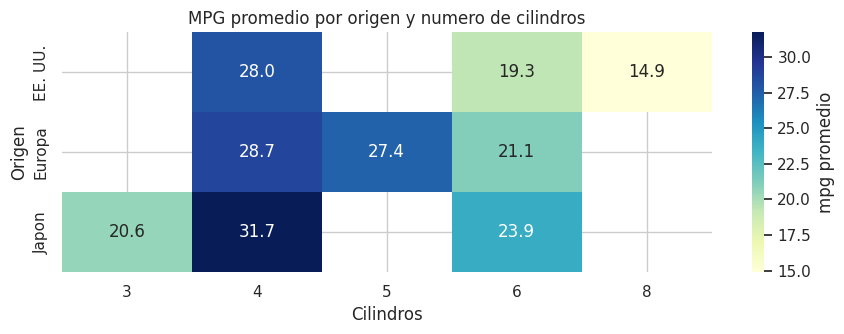

In [11]:
dos_grupos = (eda.groupby(["origen_nombre", "cylinders"])["mpg"]
              .agg(n_autos="size", promedio="mean", mediana="median")
              .round(2))
display(dos_grupos)

tabla_calor = eda.pivot_table(index="origen_nombre", columns="cylinders",
                              values="mpg", aggfunc="mean")
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(tabla_calor, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax,
            cbar_kws={"label": "mpg promedio"})
ax.set(title="MPG promedio por origen y numero de cilindros", xlabel="Cilindros", ylabel="Origen")
plt.tight_layout()
plt.show()

### 3.2 Crear categorías de una variable continua usando `pd.qcut`

A veces `groupby` necesita **intervalos**: `qcut` separa el peso en grupos con aproximadamente el mismo número de autos (cuartiles), aunque los intervalos no tengan igual ancho. Con `pd.cut` podríamos fijar límites físicos conocidos en su lugar.

**Pregunta:** ¿el `mpg` promedio desciende de forma ordenada al pasar de autos livianos a muy pesados?

,n_autos,mpg_promedio,peso_min,peso_max
grupo_peso,,,,
Q1 livianos,81,32.36,1613.0,2220.0
Q2,78,26.35,2226.0,2815.0
Q3,79,20.71,2830.0,3574.0
Q4 pesados,80,14.94,3605.0,5140.0


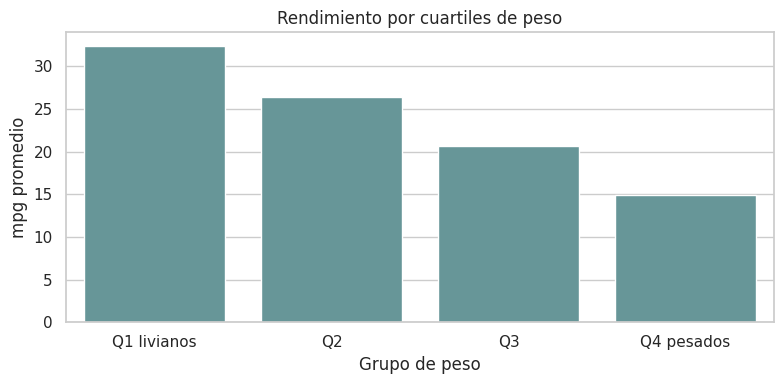

In [12]:
eda = eda.copy()
eda["grupo_peso"] = pd.qcut(
    eda["weight"], q=4,
    labels=["Q1 livianos", "Q2", "Q3", "Q4 pesados"]
)
por_peso = (eda.groupby("grupo_peso", observed=True)
            .agg(n_autos=("mpg", "size"), mpg_promedio=("mpg", "mean"),
                 peso_min=("weight", "min"), peso_max=("weight", "max")))
display(por_peso.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=por_peso.index.astype(str), y=por_peso["mpg_promedio"], ax=ax, color="cadetblue")
ax.set(title="Rendimiento por cuartiles de peso", xlabel="Grupo de peso", ylabel="mpg promedio")
plt.tight_layout()
plt.show()

### 3.3 Tendencias en el tiempo con `groupby`

El campo `model_year` va del 70 al 82 (años de modelo 1970–1982). Aquí nos interesa ver **cómo evoluciona el promedio** del rendimiento. Como los datos no son mediciones repetidas de los mismos autos, esto es una **tendencia entre modelos**, no una evolución individual.

,model_year,n_autos,mpg_promedio,mpg_mediana
0,70,23,17.74,16.00
1,71,19,21.26,19.00
2,72,19,18.32,17.00
3,73,32,17.12,17.00
4,74,22,22.64,24.00
5,75,23,19.04,18.00
6,76,31,21.39,20.00
7,77,23,23.74,22.00
8,78,31,24.78,21.10
9,79,24,25.35,24.65


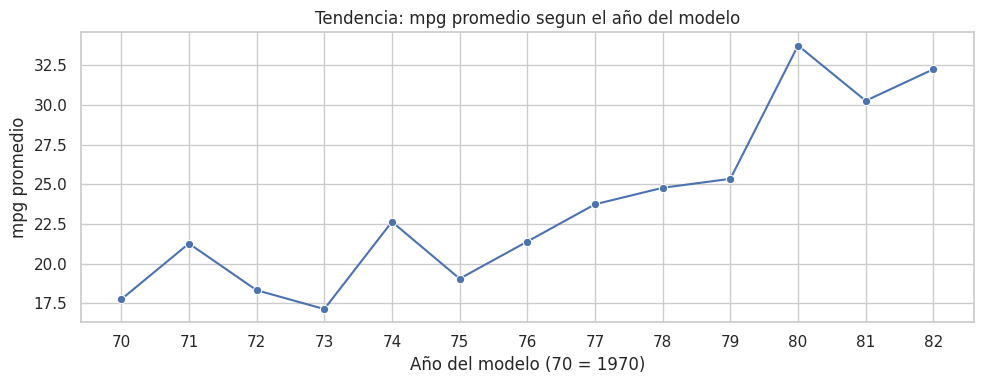

In [13]:
por_anio = (eda.groupby("model_year", as_index=False)
            .agg(n_autos=("mpg", "size"),
                 mpg_promedio=("mpg", "mean"),
                 mpg_mediana=("mpg", "median")))
display(por_anio.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=por_anio, x="model_year", y="mpg_promedio", marker="o", ax=ax)
ax.set(title="Tendencia: mpg promedio segun el año del modelo",
       xlabel="Año del modelo (70 = 1970)", ylabel="mpg promedio")
ax.set_xticks(por_anio["model_year"])
plt.tight_layout()
plt.show()

## 4. Análisis bivariado: variable explicativa frente a `mpg`

Las tablas de grupo son útiles, pero no muestran la forma de la relación entre dos variables continuas. El **diagrama de dispersión** permite observar tendencias lineales, curvaturas, subgrupos y observaciones inusuales.

En cada gráfica dibujamos una **recta de tendencia descriptiva** (`regplot`); **no es todavía el modelo final**. Los colores representan origen geográfico.

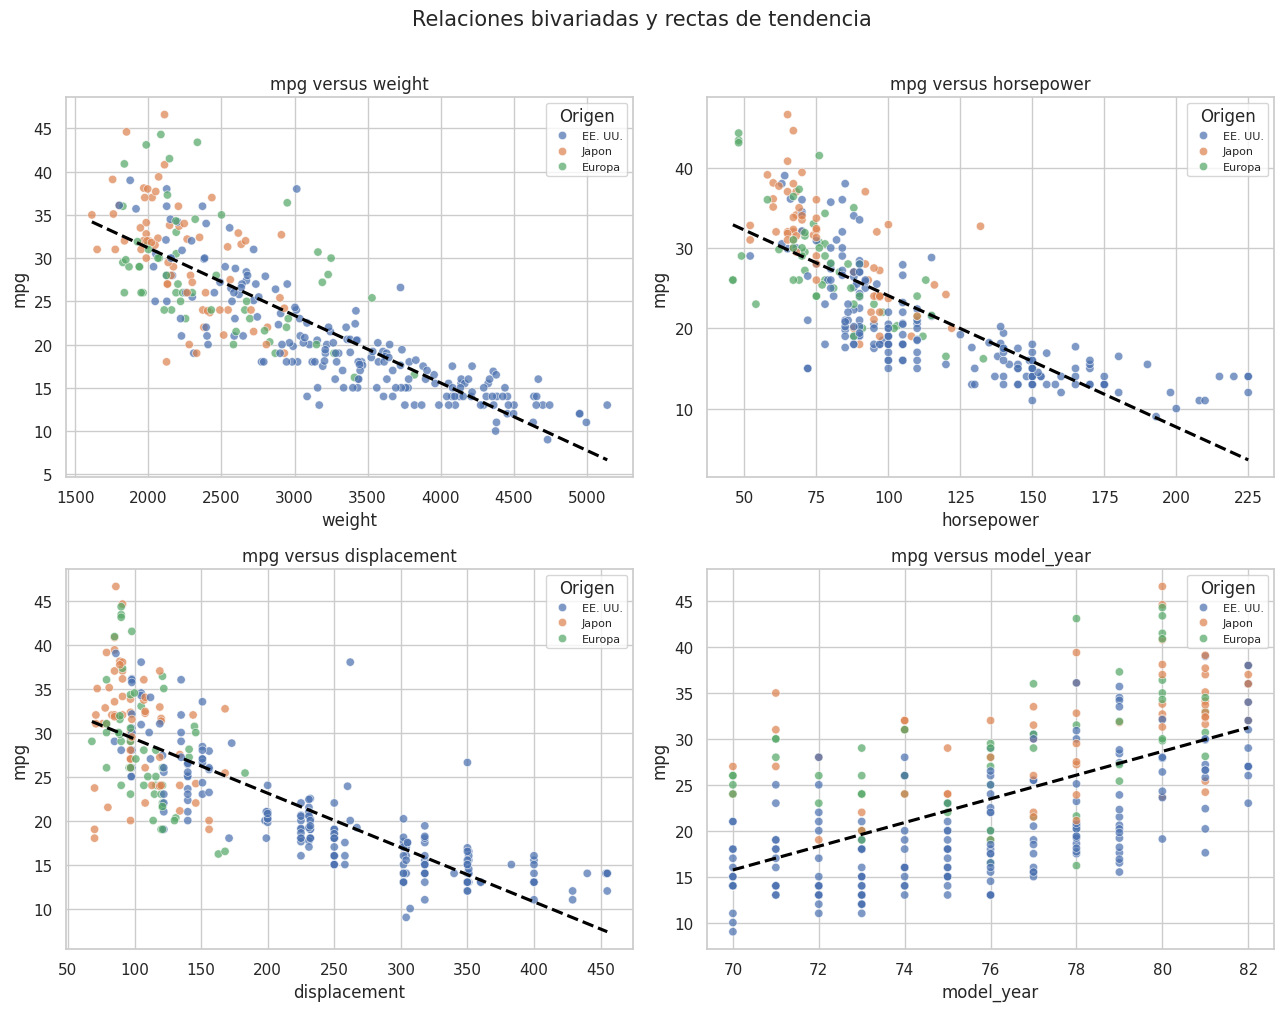

In [14]:
variables_candidatas = ["weight", "horsepower", "displacement", "model_year"]
fig, axs = plt.subplots(2, 2, figsize=(13, 10))
for ax, var in zip(axs.flat, variables_candidatas):
    sns.scatterplot(data=eda, x=var, y="mpg", hue="origen_nombre", alpha=0.72, ax=ax)
    sns.regplot(data=eda, x=var, y="mpg", scatter=False, ci=None,
                line_kws={"color": "black", "linestyle": "--"}, ax=ax)
    ax.set_title(f"mpg versus {var}")
    ax.legend(loc="best", title="Origen", fontsize=8)
plt.suptitle("Relaciones bivariadas y rectas de tendencia", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

**Discusión:** el peso (`weight`) suele mostrar una relación negativa clara: a mayor peso, menor rendimiento. `model_year` suele mostrar relación positiva. Sin embargo, **la dispersión alrededor de la recta** indica que una sola variable no explica todo.

> Una recta puede representar mal una relación curva. Antes de elegir automáticamente una regresión lineal, inspecciona si se observa una curvatura o dispersión desigual.

## 5. Correlaciones: cuantificar la intensidad de la asociación

- **Pearson (`r`)** mide asociación **lineal**, en el intervalo de −1 a 1. Un valor negativo indica que una variable tiende a disminuir cuando la otra aumenta.
- **Spearman (`ρ`)** calcula correlación entre **rangos**: puede capturar relaciones monótonas no necesariamente lineales y suele ser menos sensible a valores extremos.
- Una correlación cercana a cero **no descarta** una relación curva o por subgrupos.

**Importante:** `origin` se excluye de la matriz de Pearson como número continuo porque sus códigos son etiquetas. `cylinders` se muestra con fines exploratorios, aunque su interpretación exige cuidado.

,Pearson_con_mpg,Spearman_con_mpg
weight,-0.827,-0.869
displacement,-0.802,-0.850
horsepower,-0.772,-0.849
cylinders,-0.770,-0.818
acceleration,0.390,0.412
model_year,0.587,0.594


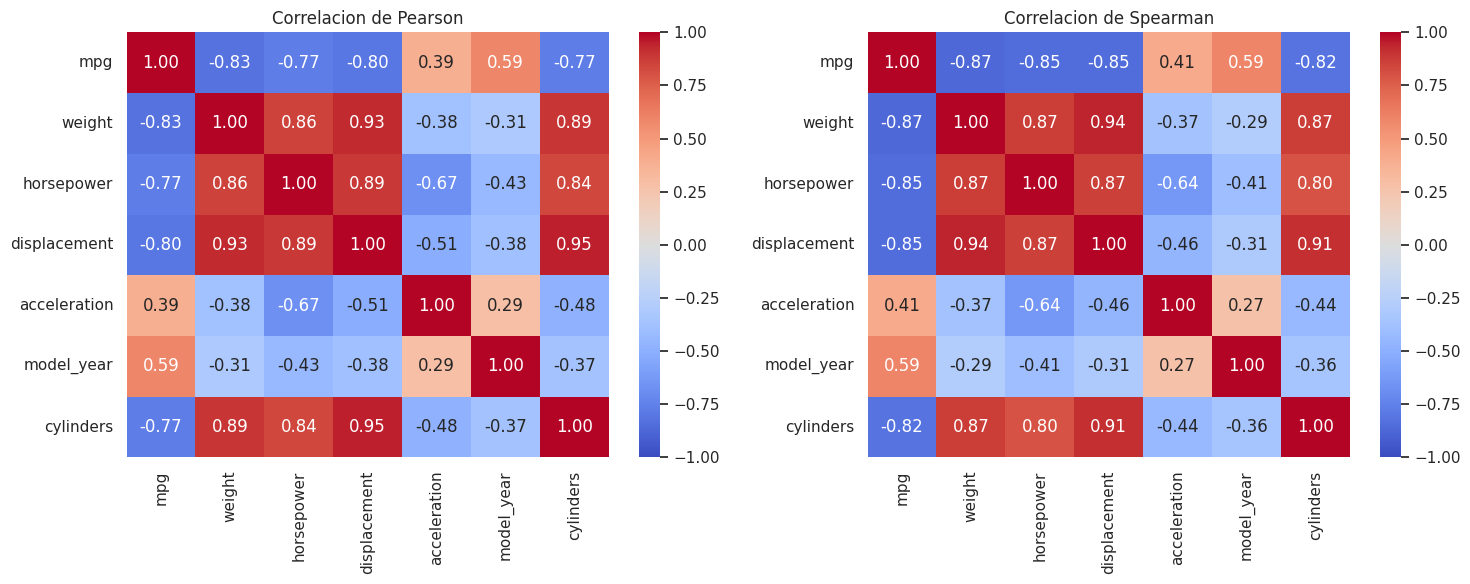

In [15]:
columnas_correlacion = ["mpg", "weight", "horsepower", "displacement",
                         "acceleration", "model_year", "cylinders"]
corr_pearson = eda[columnas_correlacion].corr(method="pearson")
corr_spearman = eda[columnas_correlacion].corr(method="spearman")

resumen_correlacion = pd.DataFrame({
    "Pearson_con_mpg": corr_pearson["mpg"],
    "Spearman_con_mpg": corr_spearman["mpg"]
}).drop(index="mpg").sort_values("Pearson_con_mpg")
display(resumen_correlacion.round(3))

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, ax=axs[0])
axs[0].set_title("Correlacion de Pearson")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, ax=axs[1])
axs[1].set_title("Correlacion de Spearman")
plt.tight_layout()
plt.show()

### 5.1 Multicolinealidad: varias columnas pueden contar casi la misma historia

Observa en el mapa de calor las relaciones entre **peso, cilindrada y potencia**. Si estas variables están fuertemente correlacionadas, un modelo con todas ellas puede predecir bien, pero los **coeficientes individuales** volverse inestables o difíciles de interpretar.

El criterio para decidir predictores no es únicamente escoger las columnas con el mayor `|r(mpg, x)|`. También debemos comprobar si cada columna **añade información** respecto de las ya seleccionadas, y si mejora la capacidad predictiva **fuera de muestra**.

,weight,displacement,horsepower,cylinders,model_year,acceleration
weight,1.00,0.93,0.86,0.89,-0.31,-0.38
displacement,0.93,1.00,0.89,0.95,-0.38,-0.51
horsepower,0.86,0.89,1.00,0.84,-0.43,-0.67
cylinders,0.89,0.95,0.84,1.00,-0.37,-0.48
model_year,-0.31,-0.38,-0.43,-0.37,1.00,0.29
acceleration,-0.38,-0.51,-0.67,-0.48,0.29,1.00


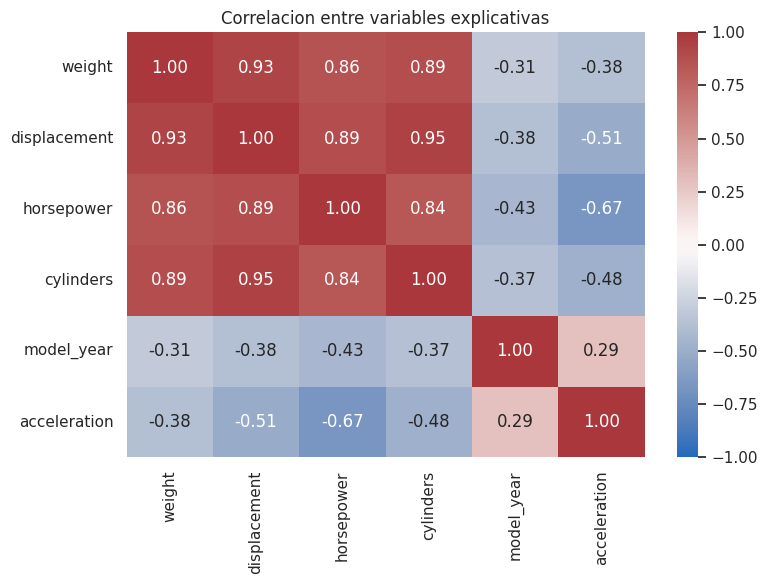

In [17]:
predictores_corr = ["weight", "displacement", "horsepower", "cylinders", "model_year", "acceleration"]
correlacion_predictoras = eda[predictores_corr].corr().round(2)
display(correlacion_predictoras)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlacion_predictoras, annot=True, fmt=".2f",
            cmap="vlag", vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title("Correlacion entre variables explicativas")
plt.tight_layout()
plt.show()

### 5.2 Gráfico de pares (visión conjunta)

Un `pairplot` dibuja las distribuciones marginales y dispersogramas de varias variables simultáneamente. Es una herramienta visual para identificar **estructuras, grupos o posibles relaciones no lineales**. Elegimos pocas columnas para conservar legibilidad.

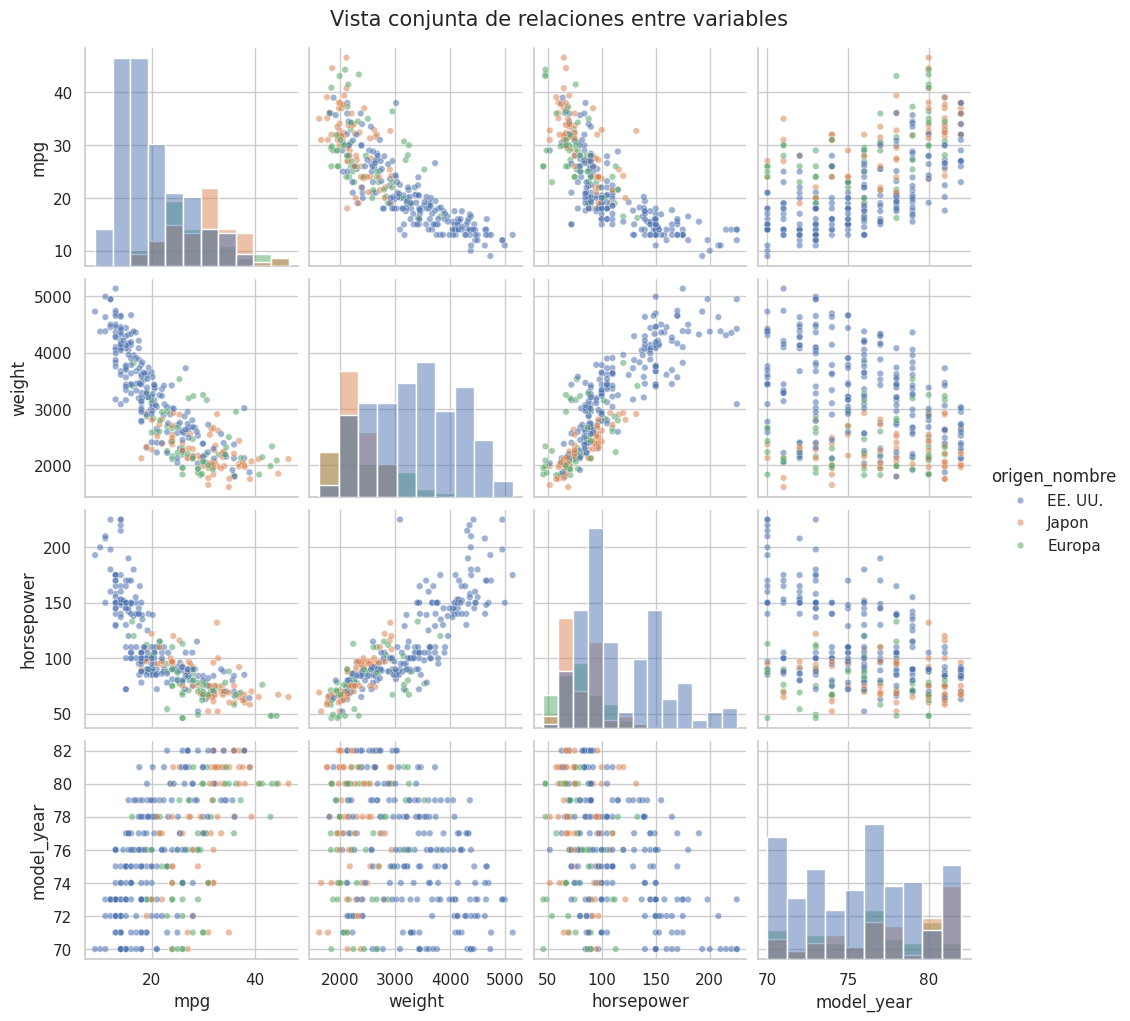

In [18]:
g = sns.pairplot(
    eda[["mpg", "weight", "horsepower", "model_year", "origen_nombre"]],
    vars=["mpg", "weight", "horsepower", "model_year"],
    hue="origen_nombre", diag_kind="hist", plot_kws={"alpha": 0.55, "s": 22}
)
g.fig.suptitle("Vista conjunta de relaciones entre variables", y=1.02, fontsize=15)
plt.show()

## 6. Primera conclusión del EDA: candidatas para explicar `mpg`

La exploración anterior permite **proponer hipótesis**, no probar causalidad:

| Variable | Evidencia descriptiva | Qué revisar antes de concluir |
|---|---|---|
| `weight` | Asociación negativa fuerte con `mpg` | Posible curvatura; relación con potencia y cilindrada. |
| `model_year` | Años más recientes suelen tener mejor `mpg` | Diferencias tecnológicas y de composición de la muestra. |
| `horsepower` | Asociación negativa notable | Datos faltantes; correlación con peso y cilindrada. |
| `displacement` | Asociación negativa notable | Información redundante respecto de peso y potencia. |
| `cylinders` | Grandes diferencias entre grupos | Grupos de tamaños desiguales y redundancia con peso. |
| `origin` | Diferencias claras de medias | Es categórica; diferencias pueden deberse en parte al peso. |
| `acceleration` | Asociación bivariada moderada | Su contribución puede cambiar al controlar otras variables. |

**Selección provisional para probar:** empezar por `weight`; después añadir `model_year`; luego `horsepower`; finalmente comparar un modelo con varias variables y `origin` como categoría.

A continuación usaremos **validación cruzada dentro del entrenamiento** para decidir entre esas opciones, conservando la prueba totalmente reservada.

## 7. De la exploración al modelo lineal

La regresión lineal múltiple ajusta, mediante mínimos cuadrados, una combinación de características para predecir `mpg`:

\[
\widehat{\mathrm{mpg}}=\beta_0+\beta_1\,\mathrm{weight}
+\beta_2\,\mathrm{model\_year}+\cdots
\]

**¿Por qué un `Pipeline`?** Si existen valores faltantes, debemos estimar la mediana **solo con las filas usadas para ajustar**. Durante validación cruzada, `Pipeline` repite la preparación dentro de cada partición; esto evita filtraciones de información.

Para `origin`, `OneHotEncoder` crea columnas indicadoras (dummies), sin tratar 1, 2 y 3 como magnitudes. Los predictores cuantitativos se conservan con su escala original.

In [19]:
def crear_modelo(columnas):
    """Crea un modelo lineal con imputacion y, si aplica, codificacion categorica."""
    categoricas = [c for c in columnas if c == "origin"]
    numericas = [c for c in columnas if c != "origin"]

    transformaciones = []
    if numericas:
        transformaciones.append(("numericas", SimpleImputer(strategy="median"), numericas))
    if categoricas:
        tratamiento_origen = Pipeline(steps=[
            ("imputar", SimpleImputer(strategy="most_frequent")),
            ("dummies", OneHotEncoder(handle_unknown="ignore", drop="first"))
        ])
        transformaciones.append(("categoricas", tratamiento_origen, categoricas))

    preparacion = ColumnTransformer(transformers=transformaciones)
    return Pipeline(steps=[
        ("preparacion", preparacion),
        ("regresion", LinearRegression())
    ])

# Modelos propuestos ANTES de inspeccionar el conjunto de prueba.
configuraciones = {
    "A. Solo peso": ["weight"],
    "B. Peso + año": ["weight", "model_year"],
    "C. Peso + año + potencia": ["weight", "model_year", "horsepower"],
    "D. Todas numericas": ["weight", "model_year", "horsepower", "displacement", "acceleration", "cylinders"],
    "E. Numericas + origen": ["weight", "model_year", "horsepower", "displacement", "acceleration", "cylinders", "origin"]
}
print("Modelos candidatos:")
for nombre, columnas in configuraciones.items():
    print(nombre, "->", columnas)

Modelos candidatos:
A. Solo peso -> ['weight']
B. Peso + año -> ['weight', 'model_year']
C. Peso + año + potencia -> ['weight', 'model_year', 'horsepower']
D. Todas numericas -> ['weight', 'model_year', 'horsepower', 'displacement', 'acceleration', 'cylinders']
E. Numericas + origen -> ['weight', 'model_year', 'horsepower', 'displacement', 'acceleration', 'cylinders', 'origin']


### 7.1 Elegir entre modelos con validación cruzada (solo entrenamiento)

La **validación cruzada de 5 particiones** divide el entrenamiento en cinco bloques. Cada modelo se entrena cinco veces sobre cuatro bloques y se valida en el restante. Promediamos métricas de validación:

- **MAE:** error absoluto promedio, en unidades de `mpg`; menor es mejor.
- **R²:** fracción de variabilidad explicada frente a predecir siempre la media; mayor es mejor; puede ser negativo fuera de muestra.

**Ojo:** comparar aquí no toca el conjunto final de prueba. Como regla didáctica, elegiremos el **menor MAE de validación cruzada** (y discutiremos si una mejora mínima justifica un modelo mucho más complejo).

,modelo,n_variables_originales,MAE_cv,MAE_cv_sd,R2_cv
0,E. Numericas + origen,7,2.683,0.160,0.803
1,B. Peso + año,2,2.720,0.163,0.796
2,C. Peso + año + potencia,3,2.729,0.170,0.794
3,D. Todas numericas,6,2.770,0.166,0.789
4,A. Solo peso,1,3.412,0.196,0.669


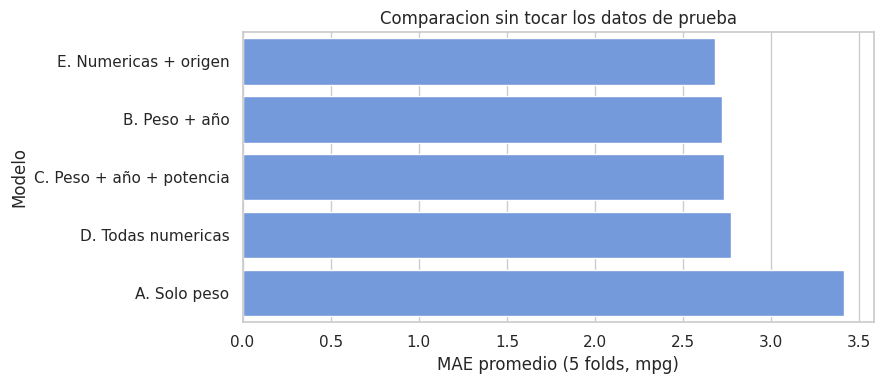

In [20]:
X_entrenamiento = entrenamiento.drop(columns=["mpg"])
y_entrenamiento = entrenamiento["mpg"]
X_prueba = prueba.drop(columns=["mpg"])
y_prueba = prueba["mpg"]

cv = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
resultados_cv = []

for nombre, columnas in configuraciones.items():
    modelo = crear_modelo(columnas)
    evaluacion = cross_validate(
        modelo,
        X_entrenamiento[columnas], y_entrenamiento,
        cv=cv,
        scoring={"MAE": "neg_mean_absolute_error", "R2": "r2"}
    )
    resultados_cv.append({
        "modelo": nombre,
        "n_variables_originales": len(columnas),
        "MAE_cv": -evaluacion["test_MAE"].mean(),
        "MAE_cv_sd": evaluacion["test_MAE"].std(),
        "R2_cv": evaluacion["test_R2"].mean()
    })

tabla_modelos = pd.DataFrame(resultados_cv).sort_values("MAE_cv").reset_index(drop=True)
display(tabla_modelos.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=tabla_modelos, x="MAE_cv", y="modelo", ax=ax, color="cornflowerblue")
ax.set(title="Comparacion sin tocar los datos de prueba", xlabel="MAE promedio (5 folds, mpg)", ylabel="Modelo")
plt.tight_layout()
plt.show()

### 7.2 Ajustar el modelo elegido y evaluar SOLO al final

Seleccionamos el modelo por MAE de validación cruzada, lo ajustamos sobre **todo el entrenamiento** y ahora sí calculamos métricas con las observaciones de prueba, que quedaron reservadas.

Para compararlo usamos también un predictor trivial que siempre anuncia el promedio de `mpg` del entrenamiento. Si nuestra regresión no supera claramente este punto de referencia, su utilidad sería limitada.

In [21]:
nombre_elegido = tabla_modelos.loc[0, "modelo"]
variables_elegidas = configuraciones[nombre_elegido]
modelo_final = crear_modelo(variables_elegidas)
modelo_final.fit(X_entrenamiento[variables_elegidas], y_entrenamiento)

predicho = modelo_final.predict(X_prueba[variables_elegidas])
modelo_base = DummyRegressor(strategy="mean")
modelo_base.fit(X_entrenamiento, y_entrenamiento)
predicho_base = modelo_base.predict(X_prueba)

# IMPORTANTE: el orden correcto es (valores_reales, predicciones).
resultado_test = pd.DataFrame([
    {"modelo": "Media del entrenamiento", "MAE": mean_absolute_error(y_prueba, predicho_base),
     "RMSE": np.sqrt(mean_squared_error(y_prueba, predicho_base)), "R2": r2_score(y_prueba, predicho_base)},
    {"modelo": nombre_elegido, "MAE": mean_absolute_error(y_prueba, predicho),
     "RMSE": np.sqrt(mean_squared_error(y_prueba, predicho)), "R2": r2_score(y_prueba, predicho)}
])
print("Modelo escogido usando SOLO validacion cruzada:", nombre_elegido)
print("Variables originales:", variables_elegidas)
display(resultado_test.round(3))

Modelo escogido usando SOLO validacion cruzada: E. Numericas + origen
Variables originales: ['weight', 'model_year', 'horsepower', 'displacement', 'acceleration', 'cylinders', 'origin']


,modelo,MAE,RMSE,R2
0,Media del entrenamiento,5.955,7.347,-0.004
1,E. Numericas + origen,2.288,2.888,0.845


### 7.3 ¿Qué significan los coeficientes de la regresión?

En el modelo lineal, cada coeficiente es el cambio esperado en `mpg` por una unidad de esa variable **manteniendo constantes las demás**, bajo los supuestos del modelo.

**Cuidado:** coeficientes de peso y año están expresados en unidades distintas; **no** se comparan sus magnitudes absolutas para concluir cuál es más importante. Además, con multicolinealidad, incluso el signo puede verse afectado. Los coeficientes de `origin` representan diferencias respecto de la categoría de referencia.

In [22]:
nombres_transformados = modelo_final.named_steps["preparacion"].get_feature_names_out()
coeficientes = pd.DataFrame({
    "variable_transformada": nombres_transformados,
    "coeficiente": modelo_final.named_steps["regresion"].coef_
}).sort_values("variable_transformada")
print("Intercepto:", round(modelo_final.named_steps["regresion"].intercept_, 3))
display(coeficientes.round(5))

Intercepto: -21.831


,variable_transformada,coeficiente
6,categoricas__origin_2,2.94786
7,categoricas__origin_3,2.67353
4,numericas__acceleration,0.06730
5,numericas__cylinders,-0.16586
3,numericas__displacement,0.01980
2,numericas__horsepower,-0.01471
1,numericas__model_year,0.82578
0,numericas__weight,-0.00704


## 8. Diagnóstico de residuales: ¿qué no está explicando el modelo?

El **residual** en prueba es `real − predicho`. Un buen modelo debe producir errores relativamente pequeños y sin patrones sistemáticos claros. Examinaremos tres perspectivas:

1. `real` frente a `predicho`: idealmente, puntos cerca de la diagonal.
2. Residuales frente a predicción: buscamos ausencia de curvas o «abanicos» (varianza creciente).
3. Histograma y gráfico Q–Q: permiten discutir asimetrías y compatibilidad con una distribución normal (la normalidad del error es más relevante para inferencia clásica que para predecir con mínimos cuadrados).

**Importante:** ver un problema en prueba no significa que debamos seguir ajustando el modelo repetidamente contra ella. Para mejoras posteriores, vuelve a entrenamiento/validación cruzada y reserva una evaluación final independiente.

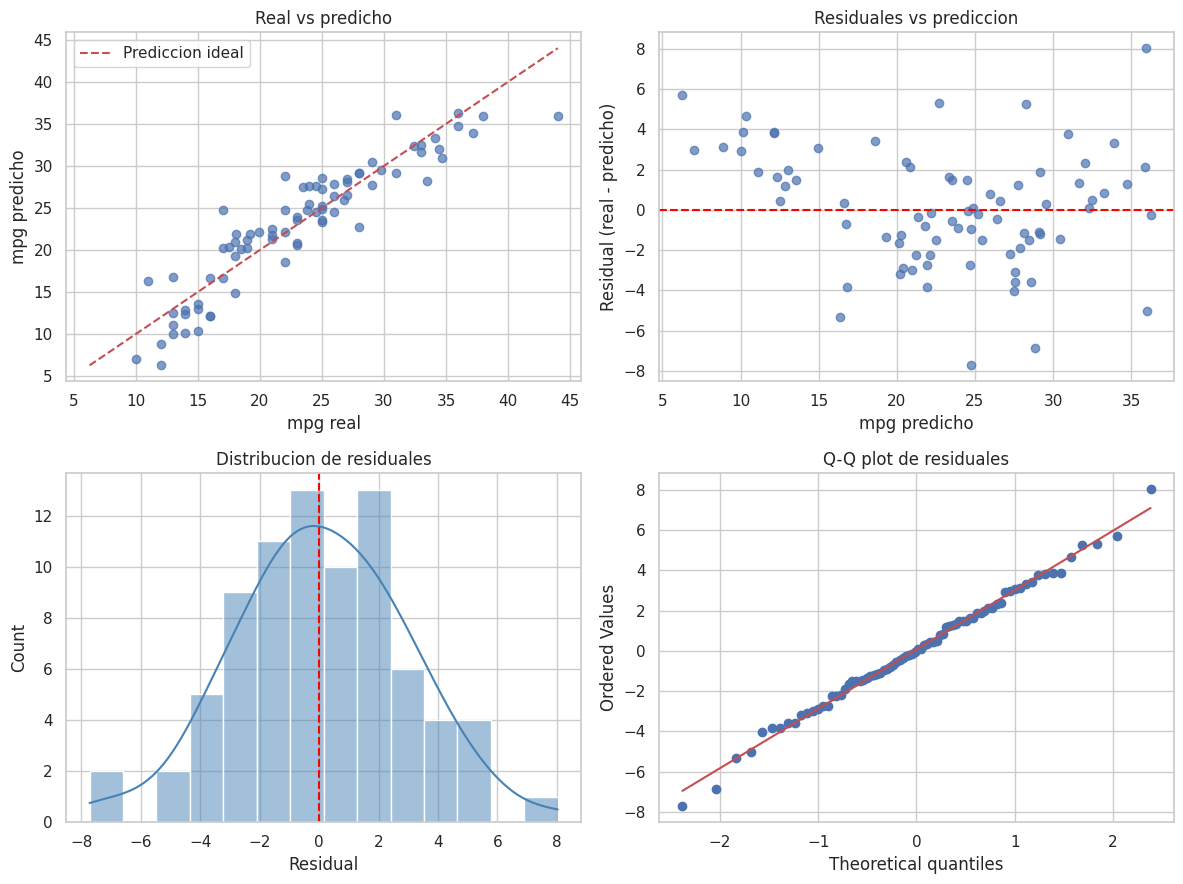

,mpg_real,mpg_predicho,error_absoluto
394,44.0,35.97,8.03
275,17.0,24.72,7.72
389,22.0,28.85,6.85
42,12.0,6.28,5.72
124,11.0,16.34,5.34
30,28.0,22.68,5.32
238,33.5,28.26,5.24
377,31.0,36.00,5.00
5,15.0,10.32,4.68
341,23.5,27.52,4.02


In [23]:
residuales_test = y_prueba.to_numpy() - predicho

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
axs[0, 0].scatter(y_prueba, predicho, alpha=0.7)
limites = [min(y_prueba.min(), predicho.min()), max(y_prueba.max(), predicho.max())]
axs[0, 0].plot(limites, limites, "r--", label="Prediccion ideal")
axs[0, 0].set(xlabel="mpg real", ylabel="mpg predicho", title="Real vs predicho")
axs[0, 0].legend()

axs[0, 1].scatter(predicho, residuales_test, alpha=0.7)
axs[0, 1].axhline(0, color="red", linestyle="--")
axs[0, 1].set(xlabel="mpg predicho", ylabel="Residual (real - predicho)", title="Residuales vs prediccion")

sns.histplot(residuales_test, bins=14, kde=True, ax=axs[1, 0], color="steelblue")
axs[1, 0].axvline(0, color="red", linestyle="--")
axs[1, 0].set(xlabel="Residual", title="Distribucion de residuales")

stats.probplot(residuales_test, dist="norm", plot=axs[1, 1])
axs[1, 1].set_title("Q-Q plot de residuales")
plt.tight_layout()
plt.show()

# Tabla legible de algunos errores (sin reordenar filas originales).
ejemplo_predicciones = pd.DataFrame({
    "mpg_real": y_prueba.to_numpy(),
    "mpg_predicho": predicho,
    "error_absoluto": np.abs(residuales_test)
}, index=y_prueba.index)
display(ejemplo_predicciones.sort_values("error_absoluto", ascending=False).head(10).round(2))

## 9. Guía de interpretación y cierre de la clase

**Hallazgos que puedes pedir a los estudiantes que expliquen con evidencia:**

1. **Distribuciones:** ¿`mpg` y el peso parecen simétricos? ¿Qué agrega un boxplot al histograma?
2. **Calidad:** ¿por qué `horsepower` tiene menos datos válidos? ¿Por qué no conviene eliminar todas las filas incompletas por defecto?
3. **Grupos:** ¿en promedio consumen menos los autos de 4 o de 8 cilindros? **Recuerda:** mayor `mpg` equivale a menor consumo por distancia recorrida.
4. **Confusión:** al agrupar por cilindros *y* origen, ¿cambia la comparación entre regiones?
5. **Correlación:** ¿qué variables tienen mayor asociación con `mpg`? ¿Qué columnas están fuertemente correlacionadas *entre sí*?
6. **Modelo:** ¿cuál tiene menor MAE de validación? ¿Agregar variables siempre ayuda?
7. **Diagnóstico:** ¿en qué regiones de `mpg` falla más el modelo? ¿Hay señales de relaciones no lineales?

### Tres ejercicios para realizar EN CLASE

**Ejercicio A.** Crear un `groupby(["model_year", "origen_nombre"])` con media y conteo de `mpg`; hacer una gráfica de líneas por origen. ¿Las tres regiones mejoran del mismo modo con el tiempo?

**Ejercicio B.** Sustituir los cuartiles de peso (`qcut`) por intervalos fijos (`pd.cut`). Comparar cuántos automóviles quedan en cada grupo y cómo cambian las medias.

**Ejercicio C.** Proponer un nuevo modelo que use solo `weight`, `model_year` y `origin`. Compararlo mediante **validación cruzada sobre entrenamiento** con el modelo escogido; no volver a ajustar usando el conjunto de prueba.

### Mensaje final

> **EDA no es decorar una regresión con gráficos:** es formular preguntas, verificar calidad, descubrir patrones, estudiar subgrupos y detectar redundancias antes de decidir qué variables entran al modelo. **Asociación ≠ causalidad**, y una buena selección de variables debe generalizar a datos no vistos.